In [2]:
import numpy as np
import matplotlib.pyplot as plt
import numpy.random as random
from scipy.signal import convolve
import scipy
from joblib import Parallel, delayed
import time
import sys
from scipy import sparse
import json
from tqdm import tqdm, tqdm_notebook
import matplotlib.gridspec as gridspec
import os
from scipy import stats
from copy import deepcopy
sys.path.insert(0, "../Scripts")
sys.path.insert(0, "../Long_Simulation")
# from antigenicWaveSimulationMethods import main as coEvoSimulation
from coverage import elementwise_coverage, coverage_1D
from fitness import fitness, norm_fitness, phage_growth
from altImmunity import immunity_loss_uniform, immunity_gain_from_kernel
from initMethods import init_trail_nh, init_1D_kernel, init_guassian_n, init_cond
from supMethods import time_conv, write2json, read_json, load_outputs
from mutation import mutation
from randomHGT import HGT_logistic_event
from formulas import gaussian1D, trail_exp
from analysisMethods import gaussian, fit_gaussian, get_tdomain

In [ ]:
from supMethods import get_xdomain


foldername = "../Data_1D_betaTest"
params, sim_params = read_json(foldername)
t_domain = get_tdomain(foldername, to_plot=False, dt = 50)
xdomain = get_xdomain(params, sim_params)

In [ ]:
def calculate_growth_rate(foldername, dt = 10):
    t_domain = get_tdomain(foldername, to_plot=False, dt  = dt)
    N_time = []

    for t in t_domain:
        n, nh = load_outputs(foldername, t, dim = 1)
        N_time.append(np.sum(n))
    N_time = np.array(N_time)

    dFdt_time = (np.diff(N_time)/N_time[:-1])/np.diff(t_domain)
    return t_domain, N_time, dFdt_time

def load_Ndata_from_superfolder(superfolder, list_to_sweep, params_to_sweep):
    subfolders = [superfolder + "/" + params_to_sweep+ f"_{i}_seed0" for i in list_to_sweep]

    M_data = []
    mean_data = []
    error_data = []

    for folder in subfolders:

        params, sim_params = read_json(folder)
        M_data.append(params[params_to_sweep])

        t_domain, N_t, dNdt = calculate_growth_rate(folder, dt = 10)

        means = [np.mean(N_t), np.mean(dNdt)]
        mean_data.append(means)

        errors = [np.std(N_t), np.std(dNdt)]
        error_data.append(errors)

    M_data = np.array(M_data)
    mean_data = np.array(mean_data)
    error_data = np.array(error_data)
    return M_data, mean_data, error_data

def return_json_from_superfolder(superfolder, list_to_sweep, params_to_sweep):
    subfolders = [superfolder + "/" + params_to_sweep+ f"_{i}_seed0" for i in list_to_sweep]
    for folder in subfolders:
        params, sim_params = read_json(folder)
    return params, sim_params

A value:  0.1333521432163324
mean dN:  2.837278849314552e-06 error:  3.4317008769878504e-05
mean N:  66446.26923076923 error:  58.204915000174296


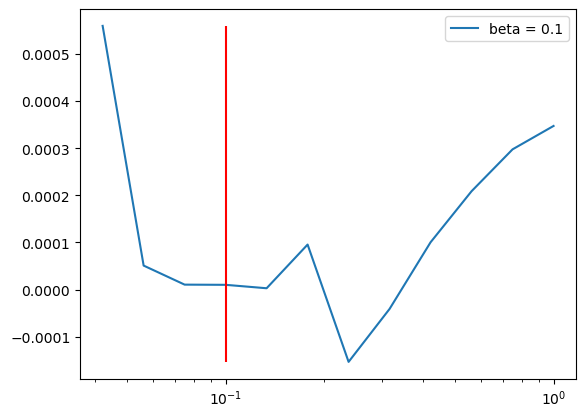

In [124]:
superfolder = "../Data_1D_A_but_for_beta_primed"
list_to_sweep = np.power(10, -1*np.arange(0, 1.5, 0.125))

beta_data, mean_data, err_data = load_Ndata_from_superfolder(superfolder, list_to_sweep, "A")
params, sim_params = return_json_from_superfolder(superfolder, list_to_sweep, "A")
beta = params["beta"]

min_ind = np.argmin(np.abs(mean_data[:, 1]))
print("A value: ", list_to_sweep[min_ind])
print("mean dN: ", mean_data[min_ind, 1],"error: " , err_data[min_ind, 1])
print("mean N: ", mean_data[min_ind, 0],"error: " , err_data[min_ind, 0])

plt.plot(list_to_sweep, mean_data[:, 1],  label = f"beta = {beta}")
plt.legend()
plt.vlines(0.1, np.min(mean_data[:, 1]), np.max(mean_data[:, 1]), color = "red")
# plt.yscale("log")
plt.xscale("log")

A value:  0.1333521432163324
mean dN:  1.280401729770944e-06 error:  3.1237288347704965e-05
mean N:  66569.01005025125 error:  109.32488073276667


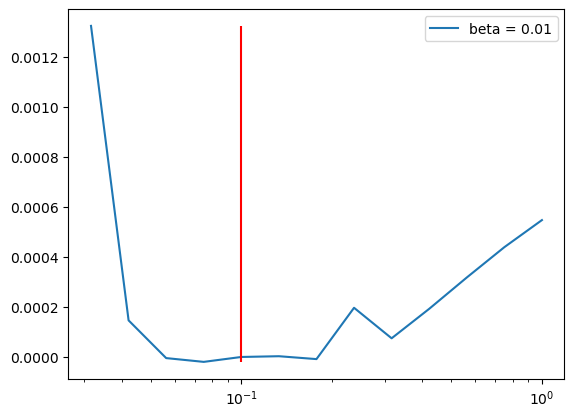

In [128]:
superfolder = "../Data_1D_A2_but_for_beta_primed"
list_to_sweep = np.power(10, -1*np.arange(0, 1.625, 0.125))

beta_data, mean_data, err_data = load_Ndata_from_superfolder(superfolder, list_to_sweep, "A")
params, sim_params = return_json_from_superfolder(superfolder, list_to_sweep, "A")
beta = params["beta"]

min_ind = np.argmin(np.abs(mean_data[:, 1]))
print("A value: ", list_to_sweep[min_ind])
print("mean dN: ", mean_data[min_ind, 1],"error: " , err_data[min_ind, 1])
print("mean N: ", mean_data[min_ind, 0],"error: " , err_data[min_ind, 0])

plt.plot(list_to_sweep, mean_data[:, 1],  label = f"beta = {beta}")
plt.legend()
plt.vlines(0.1, np.min(mean_data[:, 1]), np.max(mean_data[:, 1]), color = "red")
# plt.yscale("log")
plt.xscale("log")

A value:  0.1333521432163324
mean dN:  1.80302834141001e-06 error:  3.018945017249073e-05
mean N:  66448.88442211055 error:  110.97567169014164


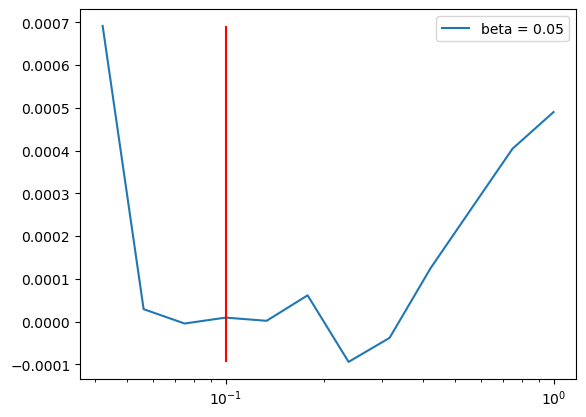

In [129]:
superfolder = "../Data_1D_A3_but_for_beta_primed"
list_to_sweep = np.power(10, -1*np.arange(0, 1.5, 0.125))

beta_data, mean_data, err_data = load_Ndata_from_superfolder(superfolder, list_to_sweep, "A")
params, sim_params = return_json_from_superfolder(superfolder, list_to_sweep, "A")
beta = params["beta"]

min_ind = np.argmin(np.abs(mean_data[:, 1]))
print("A value: ", list_to_sweep[min_ind])
print("mean dN: ", mean_data[min_ind, 1],"error: " , err_data[min_ind, 1])
print("mean N: ", mean_data[min_ind, 0],"error: " , err_data[min_ind, 0])

plt.plot(list_to_sweep, mean_data[:, 1],  label = f"beta = {beta}")
plt.legend()
plt.vlines(0.1, np.min(mean_data[:, 1]), np.max(mean_data[:, 1]), color = "red")
# plt.yscale("log")
plt.xscale("log")

0.1333521432163324